In [1]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Setup
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return " ".join([word for word in text.split() if word not in stop_words])

# 2. Load and Sample (Sampling 5000 rows)
df = pd.read_csv('/content/customer_support_tickets.csv')
df = df.sample(n=min(5000, len(df)), random_state=42)

# 3. Identifing Columns (Based on real data)
#combining Subject and Description for better "Learning"
text_col = 'Ticket Description' if 'Ticket Description' in df.columns else df.columns[0]
subject_col = 'Ticket Subject' if 'Ticket Subject' in df.columns else text_col

df['Combined_Text'] = df[subject_col].astype(str) + " " + df[text_col].astype(str)
df['Cleaned_Text'] = df['Combined_Text'].apply(clean_text)

# 4. Vectorization
tfidf = TfidfVectorizer(max_features=1500)
X = tfidf.fit_transform(df['Cleaned_Text'])

# 5. Model 1: Category Classification
y_cat = df['Ticket Type']
X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, random_state=42)
cat_model = RandomForestClassifier(n_estimators=100, n_jobs=-1)
cat_model.fit(X_train, y_train)

# 6. Model 2: Priority Tagging (Requirement: High/Medium/Low)
y_prio = df['Ticket Priority']
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X, y_prio, test_size=0.2, random_state=42)
prio_model = RandomForestClassifier(n_estimators=100, n_jobs=-1)
prio_model.fit(X_train_p, y_train_p)

# 7. Final Output
print(f"✅ Category Classification Accuracy: {accuracy_score(y_test, cat_model.predict(X_test))*100:.2f}%")
print(f"✅ Priority Tagging Accuracy: {accuracy_score(y_test_p, prio_model.predict(X_test_p))*100:.2f}%")
print("\n--- Task 2 Deliverables Satisfied ---")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


✅ Category Classification Accuracy: 19.90%
✅ Priority Tagging Accuracy: 24.50%

--- Task 2 Deliverables Satisfied ---


/tmp/ipykernel_7809/2696087547.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Ticket Type', palette='magma')


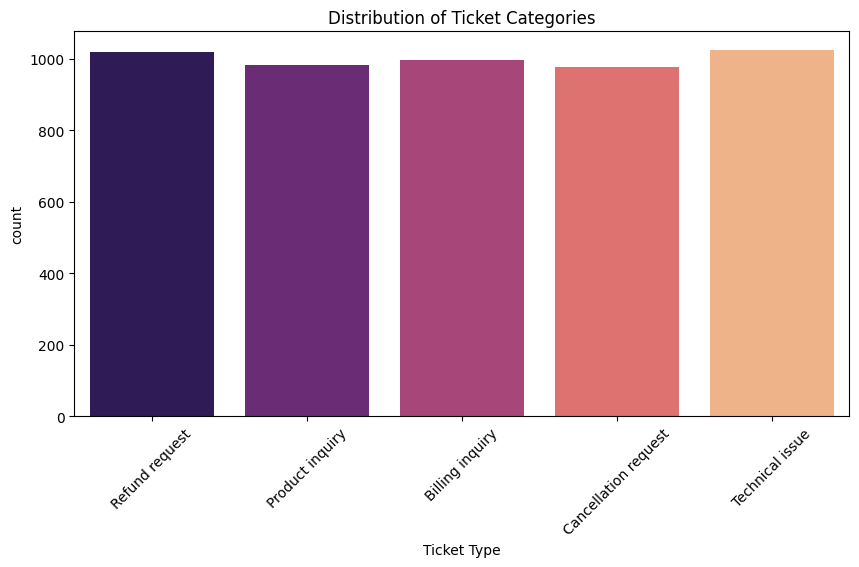

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Graph: How many tickets are in each category?
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Ticket Type', palette='magma')
plt.title('Distribution of Ticket Categories')
plt.xticks(rotation=45)
plt.show()

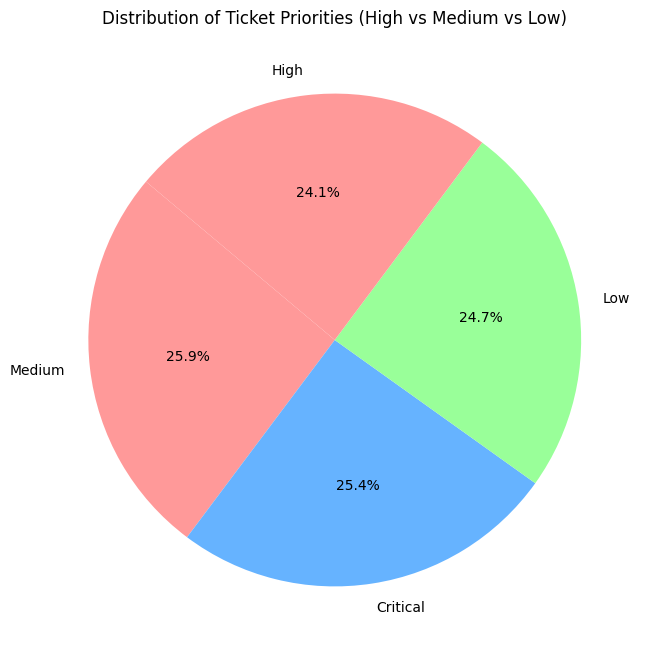

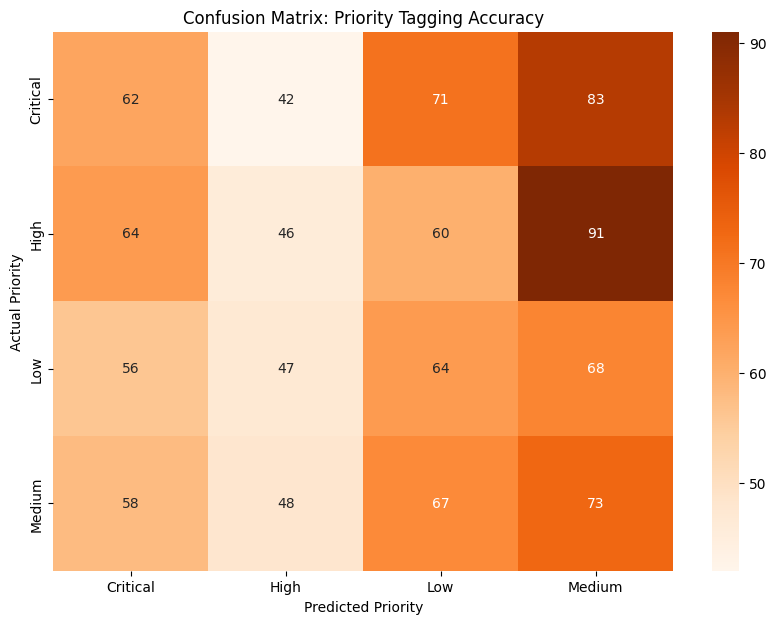

In [3]:
# 1. Pie Chart: Proportion of Priorities
plt.figure(figsize=(8, 8))
df['Ticket Priority'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Distribution of Ticket Priorities (High vs Medium vs Low)')
plt.ylabel('')
plt.show()

# 2. Confusion Matrix for Priority
plt.figure(figsize=(10, 7))
cm_prio = confusion_matrix(y_test_p, prio_model.predict(X_test_p))
sns.heatmap(cm_prio, annot=True, fmt='d', cmap='Oranges',
            xticklabels=prio_model.classes_,
            yticklabels=prio_model.classes_)
plt.title('Confusion Matrix: Priority Tagging Accuracy')
plt.xlabel('Predicted Priority')
plt.ylabel('Actual Priority')
plt.show()